In [1]:
# Activity 4 - KNN Classification

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
# Step 1 - Load Dataset

df = pd.read_csv("../../data/KNN_Activity_Data.csv")

print(df.head())
print(df.shape)

   Feature1  Feature2  Class
0      5.99      1.76      1
1      4.72      2.16      0
2      6.30      4.12      1
3      8.05      3.92      1
4      4.53      2.97      0
(300, 3)


In [3]:
# Step 2 - Features and Target

X = df[["Feature1", "Feature2"]]
y = df["Class"]

In [4]:
# Step 3 - Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [5]:
# Step 4 - Compare Different k Values

results = {}

for k in [3, 5, 8]:

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results[k] = accuracy

print("\nAccuracy for Different k Values")
print(results)



Accuracy for Different k Values
{3: 0.8444444444444444, 5: 0.8222222222222222, 8: 0.8333333333333334}


In [6]:
# Step 5 - Detailed Evaluation (k=5)

model = KNeighborsClassifier(
    n_neighbors=5
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred, digits=3))


Confusion Matrix
[[35 10]
 [ 6 39]]

Classification Report
              precision    recall  f1-score   support

           0      0.854     0.778     0.814        45
           1      0.796     0.867     0.830        45

    accuracy                          0.822        90
   macro avg      0.825     0.822     0.822        90
weighted avg      0.825     0.822     0.822        90



/workspaces/DataMining/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


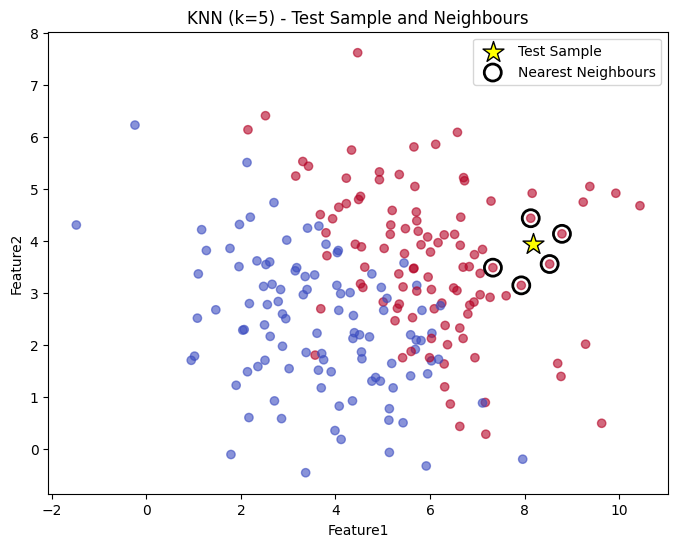

In [8]:
# Step 6 - Visualise Test Sample and Neighbours

sample = X_test.iloc[0].values.reshape(1, -1)

distances, indices = model.kneighbors(sample)

plt.figure(figsize=(8,6))

plt.scatter(
    X_train["Feature1"],
    X_train["Feature2"],
    c=y_train,
    cmap="coolwarm",
    alpha=0.6
)

plt.scatter(
    sample[:,0],
    sample[:,1],
    marker="*",
    s=250,
    c="yellow",
    edgecolor="black",
    label="Test Sample"
)

plt.scatter(
    X_train.iloc[indices[0]]["Feature1"],
    X_train.iloc[indices[0]]["Feature2"],
    s=150,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Nearest Neighbours"
)

plt.title("KNN (k=5) - Test Sample and Neighbours")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.legend()

plt.show()

## Reflection

### What happens when k changes?

k = 3
More sensitive to local patterns.
May overfit noise.
k = 5
Usually provides a good balance.
Often achieves stable accuracy.
k = 8
Smoother decision boundaries.
May underfit if important local structure is ignored.
Typical Discussion Point

Small values of k can lead to overfitting, while large values of k can lead to underfitting. The best value is usually found experimentally by comparing model accuracy across different values of k.